In [1]:
# required packages
import math
import numpy as np
import matplotlib.pyplot as plt

### Define Morse and AO Potential

In [2]:
# DEPLETION POTENTIAL
# -------------------
# Calcualte the Asakura-Oosawa-Vrij type Depletion Potential
# for more information on this calculation, see:
#   Lekkerkerker, Ruinier, Vis : Colloids and the Depletion Interaction, 2nd Edition (https://doi.org/10.1007/978-3-031-52131-7) 
#   Section 2.1 Depletion Interaction Due to Penetrable Hard Spheres, page 67
# -------------------
def depletion(r, R_C1, R_C2, r_g, c_d, M_d, phi):

  # constants
  L_m3_conversion = 1000   # 1000 L per m^3 (1L = 0.001m^3)
  Na = 6.022e23            # Avogadro's number [#/Mol]

  n_d = c_d * L_m3_conversion * (1/M_d) * Na    # depletant bulk number density : [g/L] * [L/m3] * [Mol/g] * [#/Mol] = [#/m3]
  n_d_free = n_d/(1-phi)                        # depletant number density in available solvent volume
  Pi_dynamic = n_d_free #* kT                   # osmotic pressure [J/m^3] / kT = [kT/m^3]
  h = r - (R_C1 + R_C2)                         # surface-surface separation distance [m]
    
  overlap_distance = np.where(h < 0, 0, np.maximum(0, (2 * r_g) - h))  # zero overlap if h > 2r_g OR h < 0
    
  # standard form: R_i = R_j -> R_C ; (3 * (2*(R_C1*R_C2/(R_C1+R_C2))) + 2 * r_g + h / 2)
  # for polysdisperse systems: R_i != R_j -> R_C = <R_C> = 2*(R_C1*R_C2/(R_C1+R_C2)))
  overlap_volume = (np.pi / 6) * overlap_distance**2 * (3 * (2*(R_C1*R_C2/(R_C1+R_C2))) + 2 * r_g + h / 2)
    
  return -Pi_dynamic * overlap_volume                                   # [kT/m^3] * [m^3] = [kT]


# MORSE POTENTIAL
# ---------------
# Define Morse Potential
# ---------------
def morse(r, R_C1, R_C2, D_0, alpha):
  h_ij = r - (R_C1+R_C2)
  morse_potential = D_0 * (np.exp(-2 * alpha * h_ij) - 2 * np.exp(-alpha * h_ij))
  return morse_potential

### Define Plotting Function

In [3]:
########################
# INTERACTION PARAMETERS
########################

## BRUSH HEIGHT (same for high and low)
h_b = 20

## DEPLETION
mgmL_list = [0.5, 1, 2, 3, 4, 6, 8] # concentration in [mg/mL]
D0_list = [2, 4, 9, 14, 19, 29, 38] # calculated from depletion minimum
depletant_to_D0 = dict(zip(mgmL_list, D0_list)) # zip the mapping
# delta = 17.5/550 ; alpha ~ 3/delta then scaled by brush
alpha_list = [75, 75] # Morse attraction range
r0_list = [4, 12] # Morse shift parameter

## ELECTROSTATICS
mM_list = [2.5, 3.5, 5, 10] # concentration in [mM]
Zeta_list = [33, 22, 33] # Zeta potential measurement [mV]
e0_list = [0, 2, 14] # charge distribution parameter
e0_fit_list_H = [9.9, 10.1, 10.5, 11.1] # fit charge distribution to standard Double-Layer (for numerical stability)
e0_fit_list_L = [1.2, 1.2, 1.2, 1.2]

###########
# CONSTANTS
###########
a_small = 1.1e-6           # small colloid diameter [m]
R_small = 0.5*a_small
z = 1                      # ion valence (Na+1, Cl-1)
epsilon_0 = 8.854e-12      # permittivity of free space [F/m]
e_charge = 1.602e-19       # Coulombs (electron charge) [C]
epsilon_r = 51.4           # dielectric constant AKA permittivity of 75% glycerol-water 51.4
T = 298                    # room temperature [K]
k_B = 1.381e-23            # Boltzmann constant [J/K]
Na = 6.022e23              # Avogadro's number
L_m3_conversion = 1000     # g/L = 1000 g/m^3
micron_per_DPD = R_small   # 1 sim unit = a_small/2

# Surface-surface separation distance (h_ij)
h_ij = np.linspace(-100e-9, 200e-9, 1000)


#####################
# POTENTIAL FUCNTIONS
#####################

def potential_calc(brush_type, salt, D0_val):
    # select values depending on the brush type
    if brush_type == 'L':
        brush_index = 0
    if brush_type == 'H':
        brush_index = 1

    # set values depending on the amount of salt
    if salt == 2.5:
        salt_index = 0
    if salt == 3.5:
        salt_index = 1
    if salt == 5:
        salt_index = 2
    if salt == 10:
        salt_index = 3
    
    mM = mM_list[salt_index]*1e-3
    
    # ELECTROSTATICS
    Zeta_val = Zeta_list[brush_index]*1e-3
    e0_val = e0_list[brush_index]*1e-9
    if brush_type == 'L':
        e0_fit = e0_fit_list_L[salt_index]*1e-9
    elif brush_type == 'H':
        e0_fit = e0_fit_list_H[salt_index]*1e-9
    
    ####################################
    # DEBYE LENGTH (mM dependence, only)
    ####################################
    rho_inf = 1000 * Na * mM # num ions per m**3 [#/m^3]
    numerator = rho_inf * e_charge**2 * z * 2    
    denomenator = epsilon_r * epsilon_0 * k_B * T
    kappa = np.sqrt(numerator/denomenator)
    Debye = 1/kappa
    #print(Debye)
    
    #########################
    # ELECTROSTATIC REPULSION
    #########################
    def electrostatics(Zeta, e0, e0_fit=None):
        L = 2*e0
        sigma = kappa * epsilon_0 * epsilon_r* Zeta
        
        # standard Double Layer model (Debye-Huckel Approximation)
        Z_surface = 2 * R_small * math.pi*sigma**2/(kappa**2 * epsilon_0 * epsilon_r*k_B*T)
        DLVO = Z_surface * np.exp(-kappa*h_ij)
        #print("salt =", salt, "Zeta =", Zeta, "; Z =", Z_surface)

        # charge distribution model
        h_in = np.where(h_ij < L)[0]
        h_out = np.where(h_ij >= L)[0]
        
        Z_dist = 2 * R_small * math.pi*sigma**2/(kappa**3 * epsilon_0 * epsilon_r *L**1*k_B*T)
        Electro_in = Z_dist * (np.exp(kappa*h_ij[h_in])-1) * np.exp(-kappa*h_ij[h_in])
        Electro_out = Z_dist * (np.exp(kappa*L)-1) * np.exp(-kappa*h_ij[h_out])
        Electro = np.zeros(len(h_ij))
        Electro[h_in]=Electro_in
        Electro[h_out]=Electro_out
        
        if (e0_fit != None):
            R_e1 = R_small+e0_fit
            R_e2 = R_small+e0_fit
            kT = k_B*T
            # interaction potential
            tanh = np.tanh((z*e_charge*Zeta)/(4*kT))
            Z = (64*np.pi*(epsilon_0*epsilon_r*(kT/(z*e_charge))**2*tanh**2)) # interaction constant Z [J/m]
            #print("salt =", salt, "Zeta =", Zeta, "; sim Z=Z*(R_C_real/kT) =", Z*5.5e-07/kT)
            Electro_fit = (((R_e1*R_e2)/(R_e1+R_e2)) * Z * np.exp(-kappa*(h_ij-(2*e0_fit))))/kT

        else:
            Electro_fit = [None]
        
        return Electro, Electro_fit

    Electro, Electro_fit = electrostatics(Zeta_val, e0_val, e0_fit)

    ###################
    # MORSE / DEPLETION
    ###################
    r0 = r0_list[brush_index]
    alpha = alpha_list[brush_index]
    morse_potential = D0_val * (np.exp(-2 * alpha / R_small * (h_ij - (r0*2e-9))) - 2 * np.exp(-alpha / R_small * (h_ij - (r0*2e-9))))

    return Electro, Electro_fit, morse_potential


#####################
# DEFTINE PLOT SCRIPT
#####################

def potential_plot(brush_values, salt_values, depletant_values, plot_list, plot_title, 
                   plot_bools, morse_bool, electro_bool, total_bool, save_bool):

    # Plot the potentials (U / k_B T)
    plt.figure(figsize=(8, 6))
    plt.rcParams['figure.figsize'] = [6, 6]
    plt.tick_params(
          axis='both',          # changes apply to the x-axis
          which='both',         # both major and minor ticks are affected
          bottom=False,         # ticks along the bottom edge are off
          labelbottom=False,    # labels along the bottom edge are off
          #labelleft=False,
          left=False,           # ticks along the top edge are off
          labelsize=14,
    )

    plt.axvline(0, color='black', linewidth=0.5, linestyle='-') # colloid-colloid contact
    plt.axvspan(-15, 0, alpha=0.8, color='#ababab')             # colloid region
    plt.axhline(0, color='black', linewidth=0.5, linestyle='-') # x-axis
    plt.axvspan(0, h_b*2, alpha=0.1, color='grey')              # brush region

    # label the regions
    plt.text(-13, -55, '$colloid$', fontsize=12,
                    horizontalalignment='left', verticalalignment='bottom')
    plt.text(16, -55, '$brush$', fontsize=12,
                    horizontalalignment='left', verticalalignment='bottom')

    # get D0 values from depletant selection
    D0_values = [depletant_to_D0[v] for v in depletant_values]
    
    for brush in brush_values:
        for s in range(len(salt_values)):
            salt = salt_values[s]
            for d in range(len(D0_values)):
                D0 = D0_values[d]
                depletant = mgmL_list[d]
    
                Electro, Electro_fit, morse_potential = potential_calc(brush, salt, D0)
        
                ######################
                # PLOT MORSE POTENTIAL
                ######################
                morse_color = 'crimson'
                if brush == 'L':
                    brush_index = 0
                elif brush == 'H':
                    brush_index = 1
                if morse_bool == True:
                    plt.plot(h_ij*1e9, morse_potential, linestyle='--', alpha=0.5, lw=4, color=morse_color, label=f'Morse')
                    
                #####################
                # PLOT ELECTROSTATICS
                #####################
                if electro_bool == True:
                    Electro_potential_list = [Electro, Electro_fit]
                    for index, value in enumerate(plot_bools):
                        if value:  # Check if the value is True
                
                            plot_type = plot_list[index]
                            
                            Electro_potential = Electro_potential_list[index]
                            # select labels depending on the brush type and salt
                            if brush == 'L':
                                brush_index = 0
                            if brush == 'H':
                                brush_index = 1
                            if salt == 2.5:
                                salt_index = 0
                            if salt == 3.5:
                                salt_index = 1
                            if salt == 5:
                                salt_index = 2
                            if salt == 10:
                                salt_index = 3

                            Zeta_val = Zeta_list[brush_index]
                            e0_val = e0_list[brush_index]
                            if brush == 'L':
                                e0_fit = e0_fit_list_L[salt_index]
                            elif brush == 'H':
                                e0_fit = e0_fit_list_H[salt_index]
                
                            if "fit" in plot_type:
                                e_alpha = 0.5
                                color = 'royalblue'
                                e0 = e0_fit
                                Zeta = Zeta_val
                                label_elec = "Double Layer Fit"
                                
                            else:
                                e_alpha = 1.0
                                color = 'darkorange'
                                e0 = e0_val
                                Zeta = Zeta_val
                                label_elec = "Distributed Charge"

                            if salt == 2.5:
                                salt_line = ':'
                            if salt == 3.5:
                                salt_line = 'dashdot'
                            if salt == 5:
                                salt_line = '--'
                            if salt == 10:
                                salt_line = '-'
                            
                            if "fit" in plot_type:
                                plt.plot(h_ij*1e9, Electro_potential, lw=4, alpha=0.5, linestyle='-', color=color, label=label_elec)
                            else:
                                plt.plot(h_ij*1e9, Electro_potential, lw=4, alpha=0.5, linestyle='--', color=color, label=label_elec)
                
                #######################
                # PLOT TOTAL POTENTIALS
                #######################
                if total_bool == True:
                    total = morse_potential + Electro
                    if (None not in Electro_fit):
                        total_fit = morse_potential + Electro_fit
                    else:
                        total_fit = [None]
                
                    total_potential_list = [total, total_fit]
                    for index, value in enumerate(plot_bools):
                        if value:  # Check if the value is True
                        
                            total_potential = total_potential_list[index]
                            plot_type = plot_list[index]

                            if brush == 'H':
                                color = '#189181'
                            elif brush == 'L':
                                color = '#75427A'
                            if salt == 2.5:
                                salt_line = (0,(3,5,1,5))
                            if salt == 3.5:
                                salt_line = 'dashdot'
                            if salt == 5:
                                salt_line = '--'
                            if salt == 10:
                                salt_line = '-'

                            total_label = f'Total'
                            plt.plot(h_ij*1e9, total_potential, linestyle=salt_line, color=color, lw=3, label=total_label)

    plt.xlabel("$h_{ij}$", fontsize=25)
    plt.ylabel(r"$U_{ij}^{C}/k_B T$", fontsize=25)
    
    # if only viewing electrostatics, choose a taller range to see repulsive barrier
    if (total_bool == False & morse_bool == False):
        plt.ylim(-55,150)
    else: # else, use a shorter range to emphasize the attractive well
        plt.ylim(-55,30)
    plt.xlim(-15, 100)
    
    plt.legend(loc='upper right', fontsize=20)
    if save_bool == True:
        plt.savefig(f"{plot_title}.png", format='png', dpi=300, bbox_inches='tight') 
    plt.show()


### Plotting

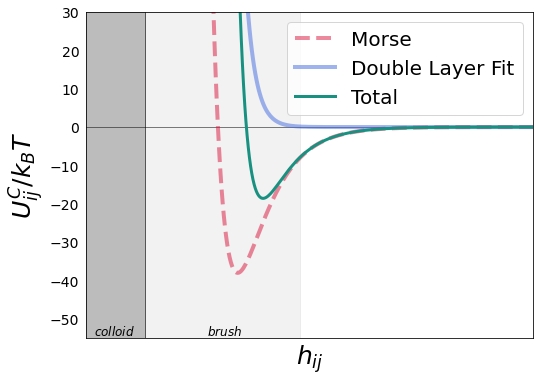

In [4]:
# use this filename to save PNG if "save_bool" == True
plot_title = 'potential_plot'

# select a subset to plot
brush_type = ['H']      # choose: ['H', 'L']
salt =[10]              # choose: [2.5, 3.5, 5, 10]
depletant_values = [8]  # choose: [0.5, 1, 2, 3, 4, 6, 8]

# choose which electrostatic repulsion to plot
plot_list = ['distributed', 'fit']
distributed = False
fit = True
plot_bools = [distributed, fit]

# use "morse_bool", "electro_bool", and "total_bool" to choose 
# whether to show Morse, Electrostatics, or Total potential curves
potential_plot(brush_type, salt, depletant_values, plot_list, plot_title, 
               plot_bools, morse_bool=True, electro_bool=True, total_bool=True, save_bool=False)

In [5]:
###################
# CHARGE PARAMETERS
###################
mM_list = [2.5, 3.5, 5, 10] # concentration in [mM]
r0_list = [0, 4, 12]

# delta = 17.5/550 ; alpha ~ 3/delta
alpha_list = [94, 75, 75]
h_b = 20
D0_list = [2, 4, 9, 14, 19, 29, 38]
mgmL_list = [0.5, 1, 2, 3, 4, 6, 8]

# old Zeta
Zeta_old_list = [50, 34, 50] # Zeta potential measurement [mV]
e0_old_list = [0, 0.01, 12] # distance from colloid surface that charge distribution extends [nm]
e0_old_fit_list_100 = [8.4, 8.6, 8.8, 9.3] # fit charge distribution -> standard Double-Layer (for simulation)
e0_old_fit_list_75 = [0.01, 0.01, 0.01, 0.01]
e0_old_fit_list_0 = [0, 0, 0, 0]

# new Zeta
Zeta_new_list = [33, 22, 33] # Zeta potential measurement [mV]
e0_new_list = [0, 2, 14]

e0_new_fit_list_100 = [9.9, 10.1, 10.5, 11.1] # fit charge distribution -> standard Double-Layer (for simulation)
e0_new_fit_list_75 = [1.2, 1.2, 1.2, 1.2]
e0_new_fit_list_0 = [0, 0, 0, 0]

###########
# CONSTANTS
###########
a_small = 1.1e-6           # small colloid diameter [m]
#R_small = (2*a_small*(0.5*a_small))/(a_small+(0.5*a_small)) 
R_small = 0.5*a_small
z = 1                      # ion valence (Na+1, Cl-1)
epsilon_0 = 8.854e-12      # permittivity of free space [F/m]
e_charge = 1.602e-19       # Coulombs (electron charge) [C]
epsilon_r = 51.4           # dielectric constant AKA permittivity of 75% glycerol-water 51.4
T = 298                    # room temperature [K]
k_B = 1.381e-23            # Boltzmann constant [J/K]
Na = 6.022e23              # Avogadro's number
L_m3_conversion = 1000     # g/L = 1000 g/m^3
micron_per_DPD = R_small   # 1 sim unit = a_small/2

# Separation distance (h_ij)
h_ij = np.linspace(-100e-9, 200e-9, 1000)

#####################
# POTENTIAL FUCNTIONS
#####################

def potential_calc(monomer, salt, D0_val):
    # select values depending on the amount of monomer
    if monomer == 0:
        monomer_index = 0
    if monomer == 75:
        monomer_index = 1
    if monomer == 100:
        monomer_index = 2

    # set values depending on the amount of salt
    if salt == 2.5:
        salt_index = 0
    if salt == 3.5:
        salt_index = 1
    if salt == 5:
        salt_index = 2
    if salt == 10:
        salt_index = 3
    
    mM = mM_list[salt_index]*1e-3
    
    # OLD ZETA
    Zeta_old = Zeta_old_list[monomer_index]*1e-3
    e0_old = e0_old_list[monomer_index]*1e-9
    if monomer == 0:
        e0_old_fit = e0_old_fit_list_0[salt_index]*1e-9
    if monomer == 75:
        e0_old_fit = e0_old_fit_list_75[salt_index]*1e-9
    elif monomer == 100:
        e0_old_fit = e0_old_fit_list_100[salt_index]*1e-9
    
    # NEW ZETA
    Zeta_new = Zeta_new_list[monomer_index]*1e-3
    e0_new = e0_new_list[monomer_index]*1e-9
    if monomer == 0:
        e0_new_fit = e0_new_fit_list_0[salt_index]*1e-9
    if monomer == 75:
        e0_new_fit = e0_new_fit_list_75[salt_index]*1e-9
    elif monomer == 100:
        e0_new_fit = e0_new_fit_list_100[salt_index]*1e-9
    
    ####################################
    # DEBYE LENGTH (mM dependence, only)
    ####################################
    rho_inf = 1000 * Na * mM # num ions per m**3 [#/m^3]
    numerator = rho_inf * e_charge**2 * z * 2    
    denomenator = epsilon_r * epsilon_0 * k_B * T
    kappa = np.sqrt(numerator/denomenator)
    Debye = 1/kappa
    #print(Debye)
    
    #########################
    # ELECTROSTATIC REPULSION
    #########################

    def electrostatics(Zeta, e0, e0_fit=None):
        L = 2*e0
        sigma = kappa * epsilon_0 * epsilon_r* Zeta
        
        # standard Double Layer model (Debye-Huckel Approximation)
        Z_surface = 2 * R_small * math.pi*sigma**2/(kappa**2 * epsilon_0 * epsilon_r*k_B*T)
        DLVO = Z_surface * np.exp(-kappa*h_ij)
        #print("salt =", salt, "Zeta =", Zeta, "; Z =", Z_surface)

        # new charge distribution model
        #"""
        h_in = np.where(h_ij < L)[0]
        h_out = np.where(h_ij >= L)[0]
        
        Z_dist = 2 * R_small * math.pi*sigma**2/(kappa**3 * epsilon_0 * epsilon_r *L**1*k_B*T)
        Electro_in = Z_dist * (np.exp(kappa*h_ij[h_in])-1) * np.exp(-kappa*h_ij[h_in])
        Electro_out = Z_dist * (np.exp(kappa*L)-1) * np.exp(-kappa*h_ij[h_out])
        Electro = np.zeros(len(h_ij))
        Electro[h_in]=Electro_in
        Electro[h_out]=Electro_out
        #"""
        #Electro = np.zeros(len(h_ij))
        #e0_fit = None
        if (e0_fit != None):
            #Electro_fit = Z_dist * (np.exp(kappa*L)-1) * np.exp(-kappa*h_ij)

            R_e1 = R_small+e0_fit
            R_e2 = R_small+e0_fit
            kT = k_B*T
            # interaction potential
            tanh = np.tanh((z*e_charge*Zeta)/(4*kT))
            Z = (64*np.pi*(epsilon_0*epsilon_r*(kT/(z*e_charge))**2*tanh**2)) # interaction constant Z [J/m]
            #print("salt =", salt, "Zeta =", Zeta, "; sim Z=Z*(R_C_real/kT) =", Z*5.5e-07/kT)
            Electro_fit = (((R_e1*R_e2)/(R_e1+R_e2)) * Z * np.exp(-kappa*(h_ij-(2*e0_fit))))/kT

        else:
            Electro_fit = [None]
        
        return DLVO, Electro, Electro_fit

    DLVO_old, Electro_old, Electro_old_fit = electrostatics(Zeta_old, e0_old, e0_old_fit)
    DLVO_new, Electro_new, Electro_new_fit = electrostatics(Zeta_new, e0_new, e0_new_fit)

    ###################
    # MORSE / DEPLETION
    ###################
    r0 = r0_list[monomer_index]
    alpha = alpha_list[monomer_index]
    morse_potential = D0_val * (np.exp(-2 * alpha / R_small * (h_ij - (r0*2e-9))) - 2 * np.exp(-alpha / R_small * (h_ij - (r0*2e-9))))

    return DLVO_old, Electro_old, Electro_old_fit, DLVO_new, Electro_new, Electro_new_fit, morse_potential


#####################
# DEFTINE PLOT SCRIPT
#####################

def plot_total_breakdown(monomer_values, salt_values, D0_values, plot_list, plot_bools, morse_true, electro_true, total_true):

    # Plot the potentials (U / k_B T)
    plt.figure(figsize=(3.5, 2.5))
    plt.rcParams['figure.figsize'] = [3.5, 2.5]
    plt.tick_params(
          axis='both',          # changes apply to the x-axis
          which='both',      # both major and minor ticks are affected
          bottom=False,      # ticks along the bottom edge are off
          labelbottom=False, # labels along the bottom edge are off
          #labelleft=False,
          left=False,         # ticks along the top edge are off
          labelsize=8,
    )

    plt.axvline(0, color='black', linewidth=0.5, linestyle='-') # colloid-colloid contact
    plt.axvspan(-15, 0, alpha=0.8, color='#ababab') # colloid region
    plt.axhline(0, color='black', linewidth=0.5, linestyle='-') # x-axis
    plt.axvspan(0, h_b*2, alpha=0.1, color='grey') # rigidity region

    #plt.text(16, -40, '$brush$', fontsize=11,
    #                horizontalalignment='left', verticalalignment='bottom')
    
    for monomer in monomer_values:
        """
        if monomer == 100:
            plt.axvspan(-10, 0, alpha=0.8, color='#b2d2cb')#color='dimgrey')
            #plt.axvspan(0, h_b*2, alpha=0.2, color='#cfe8e3')
        if monomer == 75:
            plt.axvspan(-10, 0, alpha=0.8, color='#967a9d')#color='dimgrey')
            #plt.axvspan(0, h_b*2, alpha=0.2, color='#d1bcd6')
        if monomer == 0:
            plt.axvspan(-10, 0, alpha=0.8, color='#ababab')#color='dimgrey')
        plt.axvspan(0, h_b*2, alpha=0.1, color='grey')
        """
        #plt.axvspan(-10, 0, alpha=0.8, color='#ababab')#color='dimgrey')
        #plt.axvspan(-10, 0, alpha=0.8, color='#b2d2cb')#color='dimgrey')
        #if monomer == 100:
            #plt.axvline(2*14, color='darkorange', linewidth=0.8, linestyle='--') # charge distribution, 100%
            #plt.axvline(2*14, color='#9f3b4e', linewidth=0.8, linestyle='--') # charge distribution, 100%
            #plt.axvline(2*12, color='seagreen', linewidth=0.8, linestyle='--') # Morse r0 (steric limit), 100%
        #elif monomer == 75:
            #plt.axvline(2*2, color='darkorange', linewidth=0.8, linestyle='--') # charge distribution, 75%
            #plt.axvline(2*2, color='#9f3b4e', linewidth=0.8, linestyle='--') # charge distribution, 75%
            #plt.axvline(2*4, color='seagreen', linewidth=0.8, linestyle='--') # Morse r0 (steric limit), 100%
    
        for s in range(len(salt_values)):
            salt = salt_values[s]
            for d in range(len(D0_values)):
                D0 = D0_values[d]
                depletant = mgmL_list[d]
    
                DLVO_old, Electro_old, Electro_old_fit, DLVO_new, Electro_new, Electro_new_fit, morse_potential = potential_calc(monomer, salt, D0)
        
                ######################
                # PLOT MORSE POTENTIAL
                ######################
                if monomer == 0:
                    morse_color = 'crimson' #'black'
                    monomer_index = 0
                if monomer == 100:
                    morse_color = 'crimson' #'#189181'
                    monomer_index = 2
                elif monomer == 75:
                    morse_color = 'crimson' #'#75427A'
                    monomer_index = 1
                if morse_true == True:
                    #plt.plot(h_ij*1e9, morse_potential, linestyle='--', color='purple', label=f'Morse') #$D_0$={D0}kT')
                    #plt.plot(h_ij*1e9, morse_potential, linestyle='--', lw=2, color='seagreen', label=f'Morse') #$D_0$={D0}kT')
                    
                    #plt.plot(h_ij*1e9, morse_potential, linestyle='--', lw=2, color=morse_color, label=f'Morse') #$D_0$={D0}kT')
                    #plt.plot(h_ij*1e9, morse_potential, linestyle='--', lw=2, color=morse_color, label=f'6mg/mL') #$D_0$={D0}kT')
                    plt.plot(h_ij*1e9, morse_potential, linestyle='--', alpha=0.5, lw=1.5, color=morse_color, label=f'Morse') #$D_0$={D0}kT')
                    #plt.plot(h_ij*1e9, morse_potential, linestyle='--', alpha=0.5, lw=2, color=morse_color, label=f'Morse') #$D_0$={D0}kT')
                    
                    """ plot Morse range
                    r0 = r0_list[monomer_index]
                    alpha = alpha_list[monomer_index]
                    xi = (3/alpha)*2*550
                    #print(xi)
                    plt.axvline((2*r0), color=morse_color, linewidth=0.8, linestyle='--')
                    #plt.text((2*r0)+1, -D0-10, f'$r_0={r0}nm$', fontsize=12, color=morse_color)
                    plt.text((2*r0)+1, -D0-10, f'$r_0$', fontsize=12, color=morse_color)
                    plt.axvline(xi, color=morse_color, linewidth=0.8, linestyle='--')
                    #plt.text(xi+1, -D0-10, f'$\\xi={round(xi)}nm$', fontsize=12, color=morse_color)
                    plt.text(xi+1, -D0-10, f'$\\xi_M$', fontsize=12, color=morse_color)
                    """
                    
                #####################
                # PLOT ELECTROSTATICS
                #####################
                if electro_true == True:
                    Electro_potential_list = [DLVO_old, Electro_old, Electro_old_fit, DLVO_new, Electro_new, Electro_new_fit]
                    for index, value in enumerate(plot_bools):
                        if value:  # Check if the value is True
                
                            plot_type = plot_list[index]
                            
                            Electro_potential = Electro_potential_list[index]
                            # select labels depending on the amount of monomer and salt
                            if monomer == 0:
                                monomer_index = 0
                            if monomer == 75:
                                monomer_index = 1
                            if monomer == 100:
                                monomer_index = 2
                            if salt == 2.5:
                                salt_index = 0
                            if salt == 3.5:
                                salt_index = 1
                            if salt == 5:
                                salt_index = 2
                            if salt == 10:
                                salt_index = 3
                        
                            # OLD ZETA
                            Zeta_old = Zeta_old_list[monomer_index]
                            e0_old = e0_old_list[monomer_index]
                            if monomer == 0:
                                e0_old_fit = e0_old_fit_list_0[salt_index]
                            if monomer == 75:
                                e0_old_fit = e0_old_fit_list_75[salt_index]
                            elif monomer == 100:
                                e0_old_fit = e0_old_fit_list_100[salt_index]
                
                            # NEW ZETA
                            Zeta_new = Zeta_new_list[monomer_index]
                            e0_new = e0_new_list[monomer_index]
                            if monomer == 0:
                                e0_new_fit = e0_new_fit_list_100[salt_index]
                            if monomer == 75:
                                e0_new_fit = e0_new_fit_list_75[salt_index]
                            elif monomer == 100:
                                e0_new_fit = e0_new_fit_list_100[salt_index]
                
                            if "fit" in plot_type:
                                e_alpha = 0.5
                                if "new" in plot_type:
                                    color = 'royalblue'#'#9f3b4e'#'blue'
                                    e0 = e0_new_fit
                                    Zeta = Zeta_new
                                    label_elec = "Double Layer Fit"
                                else:
                                    color = 'cadetblue'
                                    e0 = e0_old_fit
                                    Zeta = Zeta_old
                                    label_elec = "Double Layer Fit"
                            elif "DLVO" in plot_type:
                                e_alpha = 1.0
                                color = 'dodgerblue'
                                label_elec = "DLVO Repulsion"
                            else:
                                e_alpha = 1.0
                                if "new" in plot_type:
                                    color = 'darkorange'
                                    e0 = e0_new
                                    Zeta = Zeta_new
                                    label_elec = "Distributed Charge" #"Charge-Distributed DL"
                                else:
                                    color = 'tan'
                                    e0 = e0_old
                                    Zeta = Zeta_old
                                    label_elec = "Distributed Charge" #"Charge-Distributed DL"

                            if salt == 2.5:
                                salt_line = ':'#(0,(3,5,1,5))#':'
                            if salt == 3.5:
                                salt_line = 'dashdot'#'--'
                            if salt == 5:
                                salt_line = '--'#'dashdot'
                            if salt == 10:
                                salt_line = '-'
                            
                            if monomer != 0:
                                #elec_label = f'$\\zeta$={Zeta}mV, L={e0}nm ({plot_type})'
                                elec_label = str(salt)+'mM, $e_0=$'+str(round(e0_new_fit_list_100[s]+0.1))+'nm'
                                #plt.plot(h_ij*1e9, Electro_potential, alpha=e_alpha, lw=2, linestyle='--', color=color, label=elec_label)
                                #plt.plot(h_ij*1e9, Electro_potential, lw=2, linestyle='--', color=color, label=elec_label)
                                """
                                rho_inf = 1000 * Na * 10*1e-3 # num ions per m**3 [#/m^3]
                                numerator = rho_inf * e_charge**2 * z * 2    
                                denomenator = epsilon_r * epsilon_0 * k_B * T
                                kappa = np.sqrt(numerator/denomenator)
                                Debye = 1/kappa
                                Zeta = 33
                                sigma = kappa * epsilon_0 * epsilon_r* Zeta
                                color = 'royalblue'
                                sigma = kappa * epsilon_0 * epsilon_r* Zeta
                                Z_surface = 2 * R_small * math.pi*sigma**2/(kappa**2 * epsilon_0 * epsilon_r*k_B*T)
                                DLVO = Z_surface * np.exp(-kappa*h_ij)
                                plt.plot(h_ij*1e9, DLVO, lw=4, linestyle='--', color=color, label='Electrostatics')
                                """
                                if "fit" in plot_type:
                                    plt.plot(h_ij*1e9, Electro_potential, lw=1.5, alpha=0.5, linestyle='-', color=color, label='Electrostatics')
                                else:
                                    plt.plot(h_ij*1e9, Electro_potential, lw=1.5, alpha=0.5, linestyle='--', color=color, label='Electrostatics')
                                
                                #plt.plot(h_ij*1e9, Electro_potential, lw=4, alpha=0.5, linestyle='--', color=color, label=label_elec)#'Electrostatics')
                                #plt.plot(h_ij*1e9, Electro_potential, lw=4, alpha=0.5, linestyle=salt_line, color=color, label=elec_label)#'Electrostatics')
                                #plt.plot(h_ij*1e9, Electro_potential, lw=2, alpha=0.5, linestyle='--', color=color, label='Electrostatics')
                
                
                #######################
                # PLOT TOTAL POTENTIALS
                #######################
                if total_true == True:
                    total_DLVO_old = morse_potential + DLVO_old
                    total_old = morse_potential + Electro_old
                    if (None not in Electro_old_fit):
                        total_old_fit = morse_potential + Electro_old_fit
                    else:
                        total_old_fit = [None]
                    
                    total_DLVO_new = morse_potential + DLVO_new
                    total_new = morse_potential + Electro_new
                    if (None not in Electro_new_fit):
                        total_new_fit = morse_potential + Electro_new_fit
                    else:
                        total_new_fit = [None]
                
                    total_potential_list = [total_DLVO_old, total_old, total_old_fit, total_DLVO_new, total_new, total_new_fit]
                    for index, value in enumerate(plot_bools):
                        if value:  # Check if the value is True
                        
                            total_potential = total_potential_list[index]

                            #rho_inf = 1000 * Na * 10*1e-3 # num ions per m**3 [#/m^3]
                            #numerator = rho_inf * e_charge**2 * z * 2    
                            #denomenator = epsilon_r * epsilon_0 * k_B * T
                            #kappa = np.sqrt(numerator/denomenator)
                            #Debye = 1/kappa
                            #Zeta = 33
                            #sigma = kappa * epsilon_0 * epsilon_r* Zeta
                            #color = 'royalblue'
                            #sigma = kappa * epsilon_0 * epsilon_r* Zeta
                            #Z_surface = 2 * R_small * math.pi*sigma**2/(kappa**2 * epsilon_0 * epsilon_r*k_B*T)
                            #DLVO = Z_surface * np.exp(-kappa*h_ij)
                            #total_potential = morse_potential + DLVO
                            
                            plot_type = plot_list[index]
                    
                            real_potential_index = np.where(h_ij > 2e-9)[0] # cut out dips below the max repulsion
                            U_min_index = np.where(total_potential == min(total_potential[real_potential_index]))[0]
                            r_min = h_ij[U_min_index][0]
                            U_min = round(min(total_potential[real_potential_index]),1)
                            if U_min <= -4:
                                alpha_line=1.0
                            else:
                                alpha_line=0.3

                            repulsion_index = np.where(h_ij < r_min)[0]
                            attractive_index = np.where(h_ij >= r_min)[0]
                            U_rep = total_potential[repulsion_index]
                            repulsion_padding = len(repulsion_index)
                            U_att = total_potential[attractive_index]
                            round_lim = 2 # find the "zero" as 0.0# not 0.## (matches Morse delta)
                            percent = 0.1#0.04
                            U_att_rounded = []
                            for i in U_att:
                                rounded_val = round(i,round_lim) 
                                U_att_rounded.append(rounded_val)
                            end_index = []
                            #print(U_att_rounded)
                            #print(min(U_att_rounded))
                            #print(round(0.4*min(U_att_rounded),round_lim))
                            for i in range(len(U_att_rounded)):
                                val = U_att_rounded[i]
                                if val == round(percent*min(U_att_rounded),round_lim):
                                    end_index.append(i)
                            if round(percent*min(U_att_rounded),round_lim) not in U_att_rounded:
                                end_index.append(-1)
                            #end_index_val = 72
                            end_index_val = end_index[0] #U_zero_index = np.where(U_att_rounded == 0)
                            padded_end_index = repulsion_padding + end_index_val
                            U_none = total_potential[padded_end_index]
                            r_end = h_ij[padded_end_index]

                            #plt.axvline(r_min/1e-9, color='black', linewidth=0.8, linestyle='-')
                            """
                            plt.axvline(r_min/1e-9, color='black', linewidth=0.8, linestyle='--')
                            plt.text(r_min/1e-9+1, U_min-10, '$U_{min}$', fontsize=8, color='black')
                            plt.axvline(r_min/1e-9+r_end/1e-9, color='red', linewidth=0.8, linestyle='--') #color='black'
                            #plt.text(r_end/1e-9+1, U_min-10, f'$U=0$', fontsize=8, color='black')
                            plt.text(r_min/1e-9+r_end/1e-9+1, U_min-10, f'$U/D_0 \\approx${int(percent*100)}%', fontsize=8, color='red')#'black')
                            #r_end = U_none #U_att_rounded[end_index_val] #end_index_val #np.unique(U_att_rounded) #U_zero_index #U_zero_index #h_ij[U_zero_index][0]
                            print(U_min, ", range:", round((r_end/1e-9)/2,2),"nm")
                            print("r(U_min):", round((r_min/1e-9)/2,2),"nm")
                            """
                            
                            if "old" in plot_type:
                                color = 'grey'
                                if "fit" in plot_type:
                                    color = "darkolivegreen"
                            else:
                                color = 'teal'
                                if "fit" in plot_type:
                                    if monomer == 100:
                                        color = 'black' #'#7030A0'
                                    if monomer == 100:
                                        color = '#189181' #'#7030A0'
                                    elif monomer == 75:
                                        color = '#75427A' #'#CF534E'
                                        #color = "teal"
                            if "fit" in plot_type:
                                ls = '-' #'--'
                                s_index = mM_list.index(salt)
                                alpha_line = (s_index+0.75) / (len(mM_list)+0.5)
                            else:
                                ls = '-'

                            if salt == 2.5:
                                salt_line = (0,(3,5,1,5))#':'
                            if salt == 5:
                                salt_line = 'dashdot'
                            if salt == 10:
                                salt_line = '-'

                            """ # no shifts or electrostatics
                            if monomer == 75:
                                #r0 = h_b
                                #alpha = alpha_list[monomer_index]
                                #morse_bare = -U_min * (np.exp(-2 * alpha / R_small * (h_ij - (r0*2e-9))) - 2 * np.exp(-alpha / R_small * (h_ij - (r0*2e-9))))
                                alpha = 95 #alpha_list[monomer_index]
                                morse_bare = 38 * (np.exp(-2 * alpha / R_small * (h_ij)) - 2 * np.exp(-alpha / R_small * (h_ij)))
                                plt.plot(h_ij*1e9, morse_bare, linestyle='--', alpha=0.5, color='#db4e21', lw=3)
                            """
                            
                            # charge shift only (add electrostatics)
                            """
                            #r0 = h_b
                            #alpha = alpha_list[monomer_index]
                            #morse_bare = -U_min * (np.exp(-2 * alpha / R_small * (h_ij - (r0*2e-9))) - 2 * np.exp(-alpha / R_small * (h_ij - (r0*2e-9))))
                            alpha = alpha_list[monomer_index]
                            morse_bare = -U_min * (np.exp(-2 * alpha / R_small * (h_ij)) - 2 * np.exp(-alpha / R_small * (h_ij)))
                            plt.plot(h_ij*1e9, morse_bare, linestyle='-', color=color, lw=3)
                            """
                            
                            #total_label = f'$U_0=${abs(U_min)}kT ({plot_type})'
                            total_label = f'Total'
                            #total_label = f'{salt}mM: $r_n=${round(r_end/1e-9)}nm' # (rounded to {round(9*10**(-(round_lim+1)),(round_lim+1))})'
                            #total_label = f'{depletant}mg/mL: $r_n=${round(r_end/1e-9)}nm' # (rounded to {round(9*10**(-(round_lim+1)),(round_lim+1))})'
                            #total_label = f'{salt}mM'
                            #plt.plot(h_ij*1e9, total_potential, linestyle=ls, color=color, lw=2, label=total_label)                
                            #plt.plot(h_ij*1e9, total_potential, linestyle=ls, color=color, lw=2, alpha=alpha_line, label=total_label)                
                            #plt.plot(h_ij*1e9, total_potential, linestyle=ls, color=color, lw=4, alpha=alpha_line, label=total_label)
                            plt.plot(h_ij*1e9, total_potential, linestyle=salt_line, color=color, lw=1.5, label='Total') #, label=total_label)
                            #plt.plot(h_ij*1e9, total_potential, linestyle=ls, color='black', lw=4, alpha=alpha_line, label='Total')

                            #shifts but no rigidity
                            #if monomer == 75:
                            #    color = 'sandybrown'
                            #if monomer == 100:
                            #    color = 'brown'
                            #plt.plot(h_ij*1e9, total_potential, linestyle=ls, color=color, lw=3, label=total_label)
                            
                            
            
            #if monomer == 100:
            #  plt.plot([],[], linestyle=salt_line, color='black', lw=2, label=f'{salt}mM')
    """
    if ((len(monomer_values) == 1) & (len(salt_values) == 1) & (len(D0_values) == 1)):
        monomer = monomer_values[0]
        d_index = D0_list.index(D0_values[0])
        plt.title(str(monomer)+"%, "+str(mgmL_list[d_index])+r"mg/mL, "+str(salt_values[0])+r"mM", fontsize=8)
    elif ((len(monomer_values) == 1) & len(salt_values) == 1):
        monomer = monomer_values[0]
        plt.title(str(monomer)+"%, "+str(salt_values[0])+r"mM", fontsize=8)
    elif ((len(monomer_values) == 1) & (len(D0_values) == 1) & (len(salt_values) == 1)):
        monomer = monomer_values[0]
        d_index = D0_list.index(D0_values[0])
        plt.title(str(monomer)+"%, "+str(mgmL_list[d_index])+r"mg/mL", fontsize=8)    
    elif (len(monomer_values) == 1):
        monomer = monomer_values[0]
        plt.title(str(monomer)+"%", fontsize=8)
    elif ((len(salt_values) == 1) & (len(D0_values) == 1)):
        d_index = D0_list.index(D0_values[0])
        plt.title(str(mgmL_list[d_index])+r"mg/mL, "+str(salt_values[0])+r"mM", fontsize=8)
    elif (len(salt_values) == 1):
        plt.title(str(salt_values[0])+"mM", fontsize=8)
    elif (len(D0_values) == 1):
        d_index = D0_list.index(D0_values[0])
        plt.title(str(mgmL_list[d_index])+"mg/mL", fontsize=8)
    """
    #plt.xlabel("h (nm)", fontsize=8)
    plt.xlabel("$h_{ij}$", fontsize=8)
    #plt.ylabel(r"$U / k_B T$", fontsize=8)
    plt.ylabel(r"$U_{ij}^{C}/k_B T$", fontsize=8)
    #plt.ylabel(r"$U/k_B T$", fontsize=8)

    if (total_true == False & morse_true == False):
        #plt.ylim(-40,200)
        #plt.ylim(-40,150)
        #plt.ylim(-40,50)
        #plt.ylim(-55,40)
        plt.ylim(-55,30)
    else:
        plt.ylim(-55,30)
        #plt.ylim(-40,400)
    #plt.xlim(-10, 80)
    plt.xlim(-15, 70)
    plt.ylim(-55,30)
    plt.xlim(-15, 100)
    #plt.xlim(-15, 100)
    #plt.xlim(-1, 80)
    
    #plt.grid(True)
    #plt.legend(loc='center left', bbox_to_anchor=(1,0.5), fontsize=9)
    #plt.legend(loc='upper center', fontsize=8)
    #plt.legend(loc='lower center', fontsize=8)
    #plt.legend(loc='upper left', fontsize=8)
    plt.legend(loc='upper right', fontsize=8)
    #plt.legend(fontsize=8, title='Potentials', title_fontsize=8, loc='upper left', bbox_to_anchor=(1,0.5))

    plt.savefig("potential_plot.png", format='png', dpi=300, bbox_inches='tight') 
    #plt.savefig("potential_plot.pdf", format='pdf', dpi=300, bbox_inches='tight') 
    plt.show()


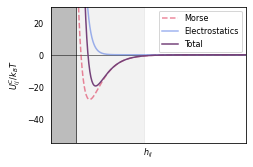

In [6]:
monomer_2 = [75] #[100, 75]
salt = [10] #[2.5, 3.5, 5, 10]
D0_values = [28] #[2, 4, 9, 14, 19, 28, 38]

# choose what to plot
old_DLVO = False
old = False
old_fit = False

new_DLVO = False
new = False
new_fit = True #False

plot_list = ['old DLVO', 'old', 'old fit', 'new DLVO', 'new', 'new fit']
plot_bools = [old_DLVO, old, old_fit, new_DLVO, new, new_fit]

plot_total_breakdown(monomer_2, salt, D0_values, plot_list, plot_bools, morse_true=True, electro_true=True, total_true=True)